# Data Wrangling – Laptop Pricing Dataset

## Overview
This project demonstrates data wrangling techniques applied to a laptop pricing dataset.

The goal is to clean, transform, and prepare the dataset for analysis by handling missing values, correcting data types, standardizing units, and creating new features.

---

## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##  Load Dataset

Load the dataset and assign column headers.

In [17]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod1.csv"

df = pd.read_csv(url)
df.drop("Unnamed: 0", axis=1, inplace=True)
df.head()

,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,Acer,4,IPS Panel,2,1,5,35.560,1.6,8,256,1.60,978
1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.20,634
2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.20,946
3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837


## Identify Missing Values

Check which values are missing in the dataset.

In [4]:
missing_data = df.isnull()
missing_data.head()

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False


## Count Missing Values

Count missing values in each column.

In [5]:
missing_data.sum()

,0
Unnamed: 0,0
Manufacturer,0
Category,0
Screen,0
GPU,0
OS,0
CPU_core,0
Screen_Size_cm,4
CPU_frequency,0
RAM_GB,0


## Handle Missing Data

- Replace numerical missing values with mean  
- Replace categorical missing values with mode  

In [19]:
# Example (adjust column names based on your dataset)

# Replace numeric column
avg_weight = df["Weight_kg"].astype("float").mean()
df["Weight_kg"] = df["Weight_kg"].replace(np.nan, avg_weight)

# Replace numerical column (Screen_Size_cm)
avg_screen = df["Screen_Size_cm"].astype("float").mean()
df["Screen_Size_cm"] = df["Screen_Size_cm"].replace(np.nan, avg_screen)

## Correct Data Types

Convert columns to appropriate numeric formats.

In [7]:
df["Weight_kg"] = df["Weight_kg"].astype("float")
df["Screen_Size_cm"] = df["Screen_Size_cm"].astype("float")

## Data Standardization

Convert weight from kg to pounds.

In [9]:
df["Weight_pounds"] = df["Weight_kg"] * 2.205

## Data Normalization

Normalize CPU frequency values between 0 and 1.

In [10]:
df["CPU_frequency"] = df["CPU_frequency"] / df["CPU_frequency"].max()

## Binning

Group Price into Low, Medium, High categories.

In [11]:
bins = np.linspace(min(df["Price"]), max(df["Price"]), 4)
group_names = ["Low", "Medium", "High"]

df["Price-binned"] = pd.cut(df["Price"], bins, labels=group_names, include_lowest=True)

df[["Price", "Price-binned"]].head()

,Price,Price-binned
0,978,Low
1,634,Low
2,946,Low
3,1244,Low
4,837,Low


## Visualization

Visualize the distribution of price bins.

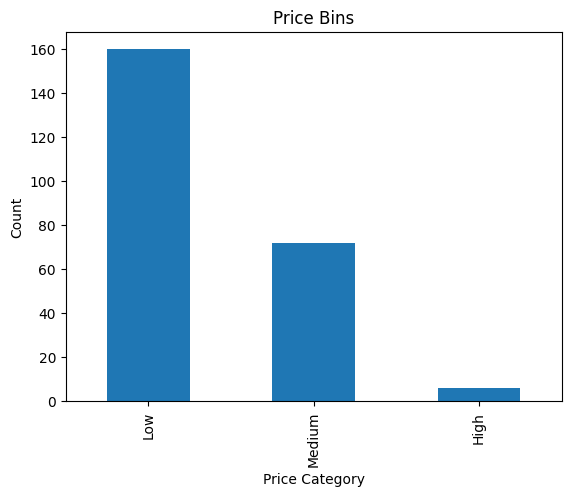

In [12]:
df["Price-binned"].value_counts().plot(kind="bar")
plt.title("Price Bins")
plt.xlabel("Price Category")
plt.ylabel("Count")
plt.show()

## Indicator Variables

Convert categorical features into numerical variables.

In [13]:
dummy_variable = pd.get_dummies(df["Screen"])
df = pd.concat([df, dummy_variable], axis=1)

df.drop("Screen", axis=1, inplace=True)

df.head()

,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price,Weight_pounds,Price-binned,Full HD,IPS Panel
0,0,Acer,4,2,1,5,35.560,0.551724,8,256,1.60,978,3.52800,Low,False,True
1,1,Dell,3,1,1,3,39.624,0.689655,4,256,2.20,634,4.85100,Low,True,False
2,2,Dell,3,1,1,7,39.624,0.931034,8,256,2.20,946,4.85100,Low,True,False
3,3,Dell,4,2,1,5,33.782,0.551724,8,128,1.22,1244,2.69010,Low,False,True
4,4,HP,4,2,1,7,39.624,0.620690,8,256,1.91,837,4.21155,Low,True,False


In [20]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Manufacturer    238 non-null    object 
 1   Category        238 non-null    int64  
 2   Screen          238 non-null    object 
 3   GPU             238 non-null    int64  
 4   OS              238 non-null    int64  
 5   CPU_core        238 non-null    int64  
 6   Screen_Size_cm  238 non-null    float64
 7   CPU_frequency   238 non-null    float64
 8   RAM_GB          238 non-null    int64  
 9   Storage_GB_SSD  238 non-null    int64  
 10  Weight_kg       238 non-null    float64
 11  Price           238 non-null    int64  
dtypes: float64(3), int64(7), object(2)
memory usage: 22.4+ KB


## Key Takeaways

- Applied data cleaning techniques on a real-world dataset  
- Transformed raw data into an analysis-ready format  
- Implemented feature engineering and normalization techniques  

## Insights

- The majority of laptops fall into the **Low price category**, indicating a skew toward budget devices  
- CPU frequency shows limited variance after normalization, suggesting similar performance ranges across models  
- Most laptops weigh under ~2.5kg, indicating portability is a dominant design factor  

## Why This Matters

This preprocessing prepares the dataset for machine learning and analysis by ensuring:

- No missing values remain  
- Data types are consistent and usable  
- Numerical features are scaled for modeling  
- Categorical variables are encoded for algorithm compatibility  